# Prerrequisitos del Sistema

**IMPORTANTE:** Antes de ejecutar el código, es necesario tener instalada la herramienta de línea de comandos `unrar` en el sistema, ya que la librería `rarfile` de Python la requiere para descomprimir los archivos.

### Instrucciones de Instalación:

* **En Linux (Debian/Ubuntu, como Google Colab):**
    ```bash
    sudo apt-get update && sudo apt-get install -y unrar
    ```
    *(La celda de código correspondiente en este notebook ya intenta ejecutar este comando).*

* **En macOS (usando Homebrew):**
    ```bash
    brew install unrar
    ```

* **En Windows:**
    1.  Descargar e instalar un programa como **WinRAR** o **7-Zip**.
    2.  Asegurarse de que la ruta al ejecutable de línea de comandos (ej. `unrar.exe`) esté añadida a la variable de entorno `PATH` del sistema.

# **Examen Práctico 1**

**De la Paz Pérez Jocelyne Arizbeth** *423072275*

17 de octubre de 2025


---

La Procuraduría Federal del Consumidor (Profeco) tiene un sitio web llamado Quién es Quién en los Precios de productos básicos (QQP), en donde se encuentran disponibles los precios de distintos productos. Una de la empresas más grandes en Retail desea analizar los datos que se encuentran de manera pública en el sitio de Profeco por lo que sebe realizar lo siguiente:

* Ingresar a la siguiente ruta: https://datos.profeco.gob.mx/datos_abiertos/qqp.php
* Descargar los archivos de datos históricos, deben de hacer uso de web scraping.
* Limpiar, unificar y homologar todos los datos.
* Realizar un análisis exploratorio (univariado, bivariado, multivariado).

---
Dado que en la página tenemos archivos comprimidos, necesitamos una librería que los descomprima. Consulté en Internet y encontré que puedo utilizar la librería `rarfile` ya que los archivos tienen extensión `.rar`. Pero para utilizar esta librería tenemos que instalar previamente la herramienta de sistema `unrar`.

Dado que son archivos muy grande con miles de datos, investigué un poco acerca de como optimizar la memoria y encontré la librería `pyarrow`, que trabaja con archivos en formato *parquet*. Usar *parquet* en lugar de formatos como *CSV* es fundamental para trabajar con grandes volúmenes de datos. `PyArrow` es la herramienta que permite a `pandas` realizar esa lectura selectiva y veloz.

**Nota:**

*Dependencia de* `unrar`: La biblioteca `rarfile` depende de la herramienta externa `unrar` para la extracción, que debe estar instalada y accesible en tu sistema.

In [ ]:
# Instalar la herramienta de sistema 'unrar'
# NOTA: El siguiente comando instala la herramienta 'unrar' en sistemas basados en Debian/Ubuntu (como Colab).
# Si este notebook se ejecuta en otro sistema operativo (Windows, macOS), esta celda puede generar un error.
!apt-get install -y unrar

# Instalar la librería de Python 'rarfile'
!pip install rarfile

# Instalar la librería de Python 'pyarrow'
!pip install pyarrow

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [ ]:
# Librerias a utilizar

import requests
from bs4 import BeautifulSoup
import rarfile # para extraer archivos .rar
from io import BytesIO # para leer archivos
import os
import pandas as pd
import glob # para buscar archivos
from IPython.display import display # para tablas bonitas
import numpy as np
import gc # para liberar memoria
import matplotlib.pyplot as plt
import seaborn as sns

### **Extraer los datos**

Inspeccionando la página observé que los datos estan divididos en años [2015-2025]. Donde cada año tiene su propia carpeta (comprimida) con archivos `.csv` con detalles sobre distintos productos a lo largo del año.

Lo primero será descargar y descomprimir estos archivos, para lo cual utilizaré web scraping.

In [ ]:

url = 'https://datos.profeco.gob.mx/datos_abiertos/qqp.php'

response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

qqp_container = soup.find('div', class_='form-group')

os.makedirs('datos_extraidos', exist_ok=True) # crear directorio

for qqp in qqp_container.find_all('li'):
    qqp_etiqueta = qqp.find('a')
    qqp_url = qqp_etiqueta['href']

    try:
        full_url = 'https://datos.profeco.gob.mx/datos_abiertos/' + qqp_url # url completa para descarga
        # print(f"Procesando: {full_url}")

        descarga = requests.get(full_url) # descargar
        descarga.raise_for_status()

        descomprime = rarfile.RarFile(BytesIO(descarga.content)) # abrir archivo
        descomprime.extractall('datos_extraidos') # descomprimir en el directorio

    except Exception as e:
        print(f"Error al procesar {qqp_url}: {e}")

print("\nExtracción de Datos: Completada\n\n")



Extracción de Datos: Completada




### **¿Cómo están mis datos?**

Antes de comenzar con la limpieza, quiero ver cómo son mis datos, cuántas variables tengo y de qué tipo. Para ello utilizo pandas para hacer un diagnóstico rápido sobre los datos de todos los años.

Después de este primer diagnóstico pude observar lo siguiente:
*   En la columna `Estado` encontré que los caracteres con acentos y la "ñ" se corrompieron.
*   La variable `Fecha_Registro` es tipo *object* (texto) en lugar de un formato de fecha.
*   El conteo de nulos mostró cientos de miles de registros sin datos en `Latitud` y `Longitud`.
*   Variables como `Presentacion,` `Tienda_Nombre`, y `Direccion` tienen miles de valores únicos.



#### **Limpieza de Datos**

Una vez que tengo los archivos descargados y un vistazo de cómo son los datos, procederé con la limpieza que, considero yo, es la fase más importante.

Teniendo en cuenta las observaciones que menciono anteriormente, haré lo siguiente:
*   Hacer un diccionario de correcciones completo para la columna de `Estado` con la finalidad de estandarizar los nombres con problemas.
*   Convertir `Fecha_Registro` a tipo *datetime* para poder filtrar por fechas.
*   Eliminar las columnas `Latitud` y `Longitud`. Aplicar imputación a estas variables creo que no es correcto porque no es un número como tal, son coordenadas. Además, tenemos muchos valores nulos. Eliminar las columnas creo que es una opción ya que aportan información muy precisa, dependerá de la profundidad del análisis que se quiera hacer, en este caso yo no las ocuparé.
*   Eliminar la columna `Direccion` y `Tienda_Nombre` ya que tiene muchos valores únicos y es muy específica. Además de que ya tenemos cómo identificar geográficamente.
*   No eliminar la columna `Presentacion`. En un principio había pensado eliminarla ya que es muy específica, pero al hacer pruebas de análisis observé que el precio difiere mucho dependiendo la presentación del producto.
*   Promediar los precios donde se encuentren valores duplicados por año.
*   Para optimizar la memoria, porque son muchísimos datos, vale la pena convertir columnas de texto a *category* y números *float64* a *float32*. Aquí es donde utilizaré el formato *parquet* para optimizar el almacenamiento.


In [ ]:
# me salia un warning sobre el formato de fecha, lo corregí en el código
import warnings
warnings.filterwarnings('ignore', message='Parsing dates in %Y-%m-%d format when dayfirst=True was specified')

path_origen = 'datos_extraidos'
path_destino = 'datos_limpios'

os.makedirs(path_destino, exist_ok=True)

nombres_columnas = [
    'Producto_Nombre', 'Presentacion', 'Marca', 'Categoria', 'Area',
    'Precio', 'Fecha_Registro', 'Cadena_Comercial', 'Tienda_Tipo',
    'Tienda_Nombre', 'Direccion', 'Estado', 'Municipio',
    'Latitud', 'Longitud'
]

def limpiar(df):
    df_limpio = df.copy()

# Implementé un diccionario para corregir los nombres. Anteriormente hice un diagnóstico
# para saber cuántas variaciones había de cada estado
    if 'Estado' in df_limpio.columns:
        df_limpio['Estado'] = df_limpio['Estado'].str.upper().str.strip()
        correcciones_estados = {
            'CIUDAD DE M\x82XICO': 'CIUDAD DE MEXICO', 'CIUDAD DE MÉXICO': 'CIUDAD DE MEXICO',
            'ESTADO DE M\x82XICO': 'ESTADO DE MEXICO', 'ESTADO DE MÉXICO': 'ESTADO DE MEXICO',
            'MICHOAC\x8dN DE OCAMPO': 'MICHOACAN', 'MICHOACÁN DE OCAMPO': 'MICHOACAN',
            'MICHOAC\xadN DE OCAMPO': 'MICHOACAN', 'NUEVO LE?N': 'NUEVO LEON',
            'NUEVO LE\x80N': 'NUEVO LEON', 'NUEVO LEÓN': 'NUEVO LEON',
            'QUER\x90TARO': 'QUERETARO', 'QUERÉTARO': 'QUERETARO',
            'SAN LUIS POTOS?': 'SAN LUIS POTOSI', 'SAN LUIS POTOSÍ': 'SAN LUIS POTOSI',
            'SAN LUIS POTOSÖ': 'SAN LUIS POTOSI', 'SAN LUIS POTOSO': 'SAN LUIS POTOSI',
            'YUCAT\x8dN': 'YUCATAN', 'YUCATÁN': 'YUCATAN', 'YUCAT\xadN': 'YUCATAN',
            'COAHUILA DE ZARAGOZA': 'COAHUILA', 'DISTRITO FEDERAL': 'CIUDAD DE MEXICO'
        }
        df_limpio['Estado'] = df_limpio['Estado'].replace(correcciones_estados)

    df_limpio['Fecha_Registro'] = pd.to_datetime(df_limpio['Fecha_Registro'], errors='coerce', dayfirst=True)
    df_limpio['Precio'] = pd.to_numeric(df_limpio['Precio'], errors='coerce')

    columnas_eliminar = ['Direccion', 'Tienda_Nombre', 'Latitud', 'Longitud']
    df_limpio.drop(columns=columnas_eliminar, inplace=True)

    return df_limpio

años = sorted([d for d in os.listdir(path_origen) if os.path.isdir(os.path.join(path_origen, d))])

for año in años:
    print(f"\n--- Procesando año: {año} ---")

    ruta_año = os.path.join(path_origen, año)
    files_año = glob.glob(os.path.join(ruta_año, "*.csv"))

    lista_df_limpios = []

    if files_año:
        for i, filename in enumerate(files_año):
            print(f"  -> Leyendo y limpiando archivo {i+1}/{len(files_año)}: {os.path.basename(filename)}")
            try:
                try:
                    df_mensual = pd.read_csv(filename, header=None, names=nombres_columnas, encoding='utf-8-sig', on_bad_lines='skip')
                except UnicodeDecodeError:
                    df_mensual = pd.read_csv(filename, header=None, names=nombres_columnas, encoding='latin1', on_bad_lines='skip')

                df_mensual_limpio = limpiar(df_mensual)
                lista_df_limpios.append(df_mensual_limpio)

                # Libera memoria
                del df_mensual, df_mensual_limpio
                gc.collect()

            except Exception as e:
                print(f"    - ERROR al procesar {os.path.basename(filename)}: {e}")

        if not lista_df_limpios:
            print(f"No se pudieron leer o limpiar archivos para el año {año}.")
            continue

        df_año_limpio = pd.concat(lista_df_limpios, ignore_index=True)

        columnas_agrupar = [col for col in df_año_limpio.columns if col != 'Precio']
        df_agrupado = df_año_limpio.groupby(columnas_agrupar, as_index=False).agg(
            Precio_Promedio=('Precio', 'mean')
        )

        for col in df_agrupado.select_dtypes(include=['object']).columns:
            df_agrupado[col] = df_agrupado[col].astype('category')
        for col in df_agrupado.select_dtypes(include=['float64']).columns:
            df_agrupado[col] = df_agrupado[col].astype('float32')

        ruta_salida = os.path.join(path_destino, f'{año}.parquet')
        df_agrupado.to_parquet(ruta_salida)

        print(f"  Año {año} guardado en: {ruta_salida} | Dimensiones: {df_agrupado.shape}")

        del lista_df_limpios, df_año_limpio, df_agrupado
        gc.collect()
    else:
        print(f"No se encontraron archivos CSV en la carpeta '{ruta_año}'")

print("\n\nProceso de limpieza completado para todos los años")



--- Procesando año: 2015 ---
  -> Leyendo y limpiando archivo 1/53: 212015.csv
  -> Leyendo y limpiando archivo 2/53: 312015.csv
  -> Leyendo y limpiando archivo 3/53: 222015.csv
  -> Leyendo y limpiando archivo 4/53: 332015.csv
  -> Leyendo y limpiando archivo 5/53: 112015.csv
  -> Leyendo y limpiando archivo 6/53: 122015.csv
  -> Leyendo y limpiando archivo 7/53: 322015.csv
  -> Leyendo y limpiando archivo 8/53: 452015.csv
  -> Leyendo y limpiando archivo 9/53: 012015.csv
  -> Leyendo y limpiando archivo 10/53: 442015.csv
  -> Leyendo y limpiando archivo 11/53: 522015.csv
  -> Leyendo y limpiando archivo 12/53: 132015.csv
  -> Leyendo y limpiando archivo 13/53: 262015.csv
  -> Leyendo y limpiando archivo 14/53: 302015.csv
  -> Leyendo y limpiando archivo 15/53: 472015.csv
  -> Leyendo y limpiando archivo 16/53: 352015.csv
  -> Leyendo y limpiando archivo 17/53: 432015.csv
  -> Leyendo y limpiando archivo 18/53: 102015.csv
  -> Leyendo y limpiando archivo 19/53: 042015.csv
  -> Leyen

#### **Análisis de Datos**

Una vez que tenemos nuestros datos limpios, procederemos a hacer un análisis (univariado, bivariado y multivariado).

Primero lo que hice fue preparar el estilo visual para los gráficos que realizé y luego buscar todos los archivos de datos con extensión *.parquet* en la carpeta `datos_limpios` para confirmar que existen antes de continuar con el análisis.

In [ ]:
# lienzo para graficar
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12

path_limpios = 'datos_limpios'
files_parquet = glob.glob(os.path.join(path_limpios, "*.parquet"))

if not files_parquet:
    print("Error: No se encontraron archivos parquet")
else:
    print(f" Se encontraron {len(files_parquet)} archivos parquet listos para el análisis.")


 Se encontraron 11 archivos parquet listos para el análisis.


##### **Análisis Univariado**

En esta primera etapa, realizaré un **Análisis Univariado** para entender la composición de los datos. El objetivo que me planteé es identificar las cadenas comerciales con mayor presencia en el conjunto de datos que obtuve de la Profeco, es decir, *¿cuáles son las cadenas comerciales más monitoreadas por la Profeco?*

Para ello, se contará la frecuencia de cada `Cadena_Comercial` a lo largo de todos los años y se visualizarán únicamente las 15 principales mediante un gráfico de barras horizontales.


--- Análisis Univariado ---




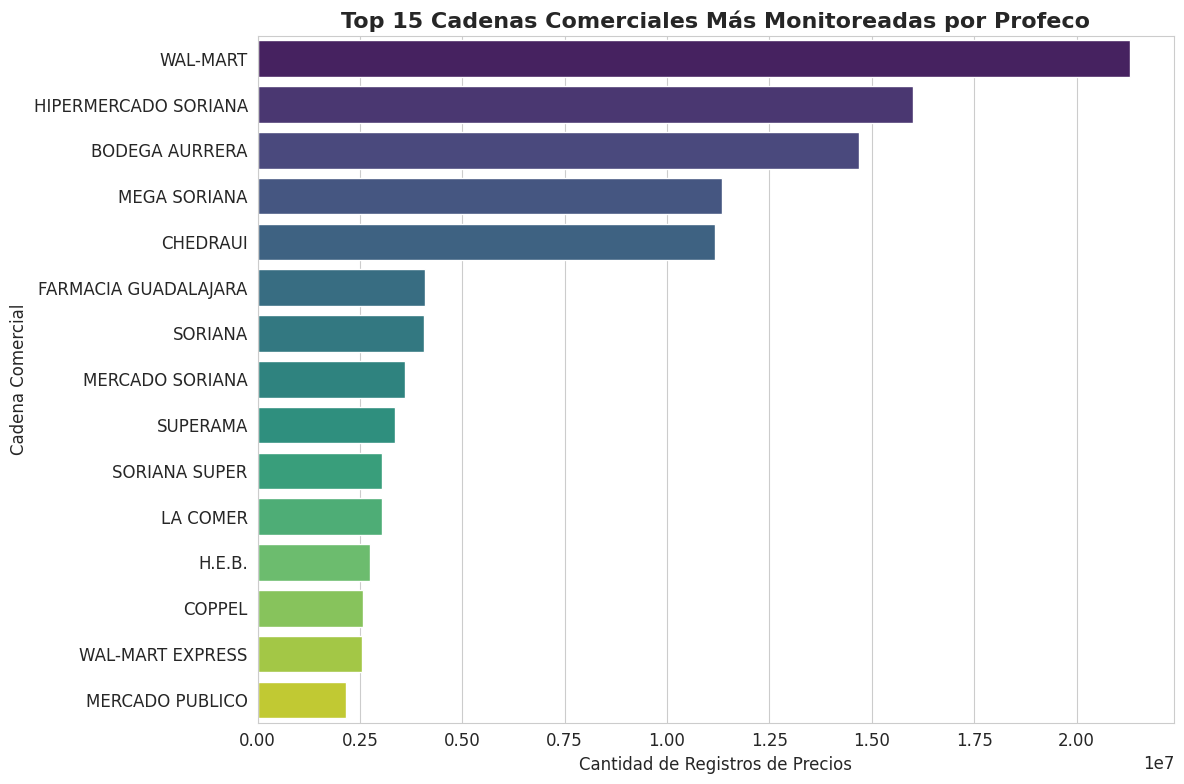

In [ ]:
# ANÁLISIS UNIVARIADO

print("\n--- Análisis Univariado ---\n\n")
total_conteo = pd.Series(dtype='int64')
for file in files_parquet:
    columna_univariado = pd.read_parquet(file, columns=['Cadena_Comercial'])
    file_conteo = columna_univariado['Cadena_Comercial'].value_counts()
    total_conteo = total_conteo.add(file_conteo, fill_value=0)

top_cadenas = total_conteo.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_cadenas.values, y=top_cadenas.index, hue=top_cadenas.index, palette='viridis', orient='h', legend=False)
plt.title('Top 15 Cadenas Comerciales Más Monitoreadas por Profeco', fontsize=16, fontweight='bold')
plt.xlabel('Cantidad de Registros de Precios', fontsize=12)
plt.ylabel('Cadena Comercial', fontsize=12)
plt.tight_layout()
plt.show()

##### **Análisis Bivariado**

Después, haré un **Análisis Bivariado** para explorar la relación entre dos variables clave: **precio y tiempo**. El propósito ahora para este análisis es visualizar ¿cómo ha evolucionado el costo de dos productos de alto consumo en México?

Aquí quise hacer dos análisis, uno para la *Totilla de Maiz* y otro para el refresco de *Coca Cola*, ya que considero son dos productos que la mayoría de las familias mexicanas consume.

Generaré dos gráficos de líneas independientes: uno para la `Coca-Cola` en su presentación de 1 Lt No Retornable (ya que hay registros en diferentes presentaciones) y otro para la `Tortilla de Maíz` por kilogramo. Este análisis permitirá identificar tendencias de inflación, estacionalidad y otros patrones a lo largo de los años.


--- Análisis Bivariado ---




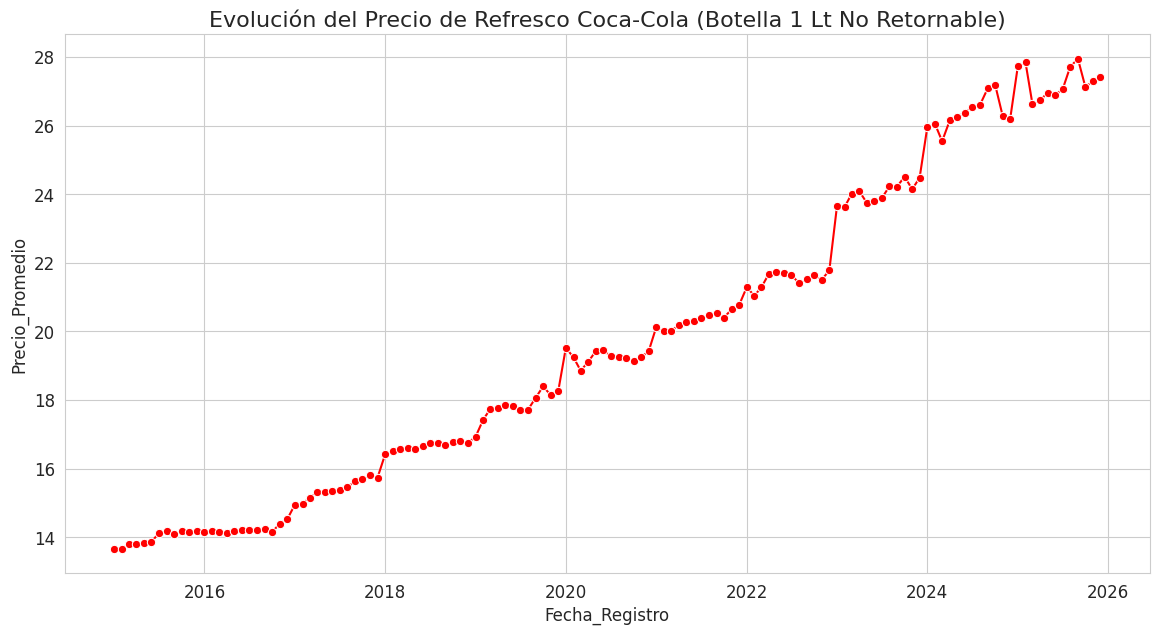

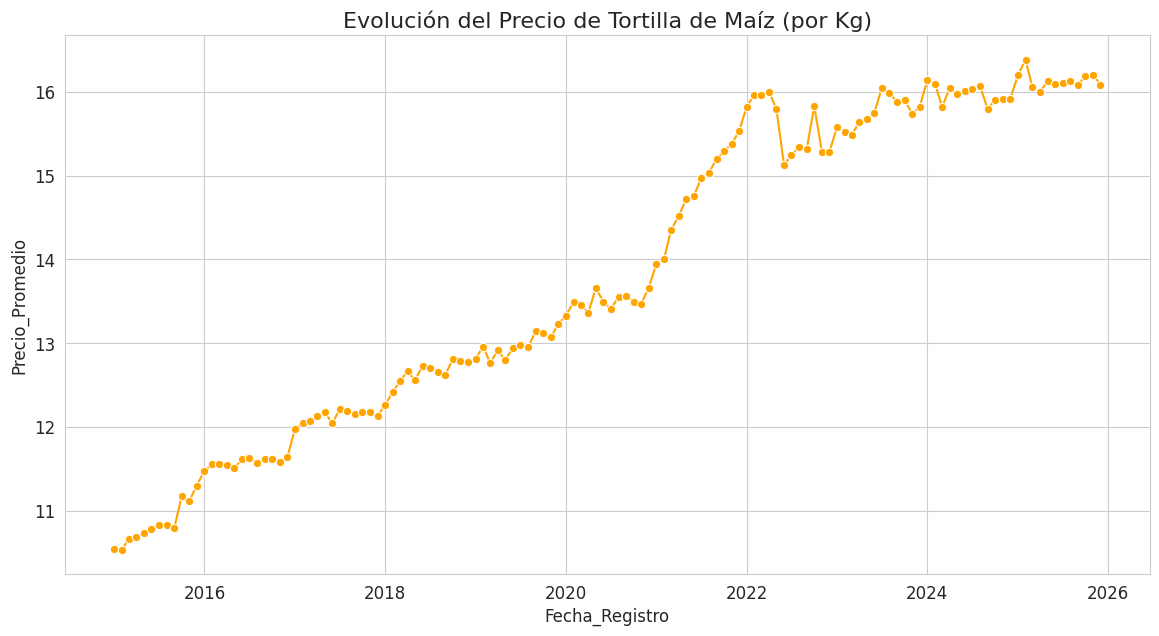

In [ ]:
# ANÁLISIS BIVARIADO

print("\n--- Análisis Bivariado ---\n\n")
lista_coca = []
lista_tortilla = []

columnas_bivariado = ['Marca', 'Producto_Nombre', 'Presentacion', 'Fecha_Registro', 'Precio_Promedio']

marca_coca = r'\bCOCA\b'
presentacion_coca = 'BOTELLA.*1 ?LT.*NO RETORNABLE'
producto_tortilla = 'TORTILLA DE MA.?Z'
presentacion_tortilla = r'\b(?:KG|KILO)\b'

for file in files_parquet:
    try:
        carga_col = pd.read_parquet(file, columns=columnas_bivariado)

        coca_filtro = carga_col[
            carga_col['Marca'].str.contains(marca_coca, case=False, na=False, regex=True) &
            carga_col['Presentacion'].str.contains(presentacion_coca, case=False, na=False, regex=True)
        ]
        if not coca_filtro.empty:
            lista_coca.append(coca_filtro)

        tortilla_filtro = carga_col[
            carga_col['Producto_Nombre'].str.contains(producto_tortilla, case=False, na=False, regex=True) &
            carga_col['Presentacion'].str.contains(presentacion_tortilla, case=False, na=False, regex=True)
        ]
        if not tortilla_filtro.empty:
            lista_tortilla.append(tortilla_filtro)
    except Exception as e:
        print(f"Advertencia al procesar {file}: {e}")

# Gráfica Coca
if lista_coca:
    df_coca = pd.concat(lista_coca, ignore_index=True)
    df_coca['Fecha_Registro'] = pd.to_datetime(df_coca['Fecha_Registro'])
    coca_evolucion = df_coca.groupby(df_coca['Fecha_Registro'].dt.to_period('M'))['Precio_Promedio'].mean().reset_index()
    coca_evolucion['Fecha_Registro'] = coca_evolucion['Fecha_Registro'].dt.to_timestamp()

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=coca_evolucion, x='Fecha_Registro', y='Precio_Promedio', marker='o', color='red')
    plt.title('Evolución del Precio de Refresco Coca-Cola (Botella 1 Lt No Retornable)', fontsize=16)
    plt.show()
else:
    print("No se encontraron datos para Coca-Cola Botella 1 Lt No Retornable.")

print("\n")

# Gráfica Tortilla
if lista_tortilla:
    df_tortilla = pd.concat(lista_tortilla, ignore_index=True)
    df_tortilla['Fecha_Registro'] = pd.to_datetime(df_tortilla['Fecha_Registro'])
    tortilla_evolucion = df_tortilla.groupby(df_tortilla['Fecha_Registro'].dt.to_period('M'))['Precio_Promedio'].mean().reset_index()
    tortilla_evolucion['Fecha_Registro'] = tortilla_evolucion['Fecha_Registro'].dt.to_timestamp()

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=tortilla_evolucion, x='Fecha_Registro', y='Precio_Promedio', marker='o', color='orange')
    plt.title('Evolución del Precio de Tortilla de Maíz (por Kg)', fontsize=16)
    plt.show()
else:
    print("No se encontraron datos para Tortilla por Kg.")


##### **Análisis Multivariado**

Finalmente, realizaré un **Análisis Multivariado** para investigar la interacción simultánea de tres variables: **precio, tiempo y estado**. El objetivo aquí es comparar si la evolución del precio de un producto clave, el `Jitomate por Kg`, ha sido uniforme a nivel nacional o si existen diferencias regionales significativas.

Seleccionaré solo una muestra de cinco estados clave: `Ciudad de México`, `Jalisco`, `Nuevo León`, `Yucatán` y `Baja California`, y graficaré la evolución de su precio promedio mensual en un solo gráfico multilínea. Esto nos puede permitir observar si los ciclos de precios o los eventos inesperados (en la economía) afectan de la misma manera a las distintas regiones de México.

Elegí a Ciudad de México, Jalisco y Nuevo León porque son tres de las áreas metropolitanas más grandes y económicamente importantes del país. A Baja California y Yucatán porque son penínsulas (una al norte y otra al sur), creo que incluirlas es interesante porque los precios en estas zonas pueden ser más altos o comportarse de manera diferente debido a los costos de transporte y logística desde los centros de producción del país. Un gráfico con los 32 estados se vería como un "gráfico de espagueti" , lo que sería más difícil de interpretar.


--- Análisis Multivariado ---


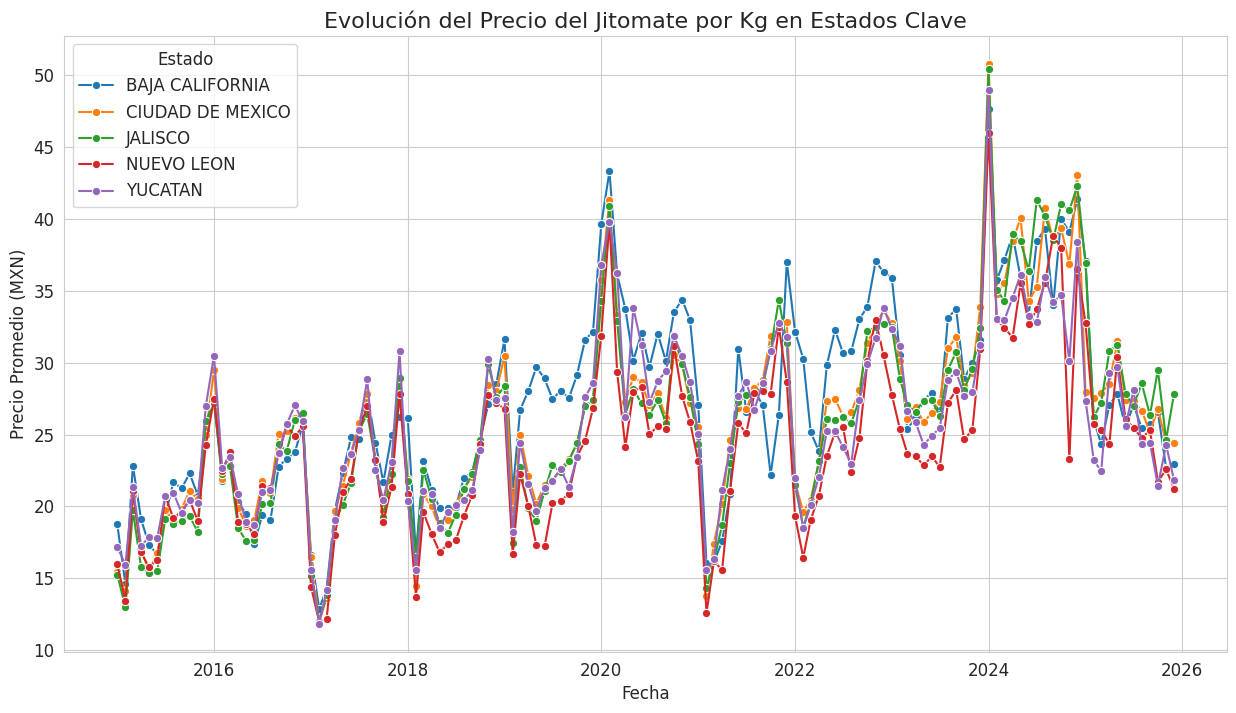

In [ ]:
# ANÁLISIS MULTIVARIADO

print("\n--- Análisis Multivariado ---")
lista_jitomate = []
columnas_multivariado = ['Estado', 'Fecha_Registro', 'Precio_Promedio', 'Producto_Nombre', 'Presentacion']

producto = r'(?:JITOMATE)'
presentacion = r'\b(?:KG|KILO)\b'

estados_a_comparar = ['CIUDAD DE MEXICO', 'JALISCO', 'NUEVO LEON', 'YUCATAN', 'BAJA CALIFORNIA']

for file in files_parquet:
    try:
        cargar_colu = pd.read_parquet(file, columns=columnas_multivariado)
        cargar_colu = cargar_colu[cargar_colu['Estado'].isin(estados_a_comparar)]

        jitomate_filtro = cargar_colu[
            cargar_colu['Producto_Nombre'].str.contains(producto, case=False, na=False, regex=True) &
            cargar_colu['Presentacion'].str.contains(presentacion, case=False, na=False, regex=True)
        ]

        if not jitomate_filtro.empty:
            lista_jitomate.append(jitomate_filtro)

    except Exception as e:
        print(f"Advertencia al procesar {file}: {e}")

if lista_jitomate:
    df_jitomate = pd.concat(lista_jitomate, ignore_index=True)
    df_jitomate['Fecha_Registro'] = pd.to_datetime(df_jitomate['Fecha_Registro'])

    evolucion_regional = df_jitomate.groupby([df_jitomate['Fecha_Registro'].dt.to_period('M'), 'Estado'])['Precio_Promedio'].mean().reset_index()
    evolucion_regional['Fecha_Registro'] = evolucion_regional['Fecha_Registro'].dt.to_timestamp()

    plt.figure(figsize=(15, 8))
    sns.lineplot(data=evolucion_regional, x='Fecha_Registro', y='Precio_Promedio', hue='Estado', marker='o', palette='tab10')
    plt.title('Evolución del Precio del Jitomate por Kg en Estados Clave', fontsize=16)
    plt.xlabel('Fecha')
    plt.ylabel('Precio Promedio (MXN)')
    plt.legend(title='Estado')
    plt.show()
else:
    print("\nAnálisis finalizado: No se encontraron datos suficientes para el análisis.")
